In [1]:
# Customer Churn Prediction for a Telecom Company

# Phase 10 – Model Evaluation

# Objective
# Evaluate the tuned machine learning models using various classification metrics and visualizations.

# Tasks
# - Load tuned models
# - Evaluate on test data
# - Generate confusion matrices
# - Plot ROC curves
# - Plot Precision-Recall curves
# - Compare model performance
# - Save evaluation reports and graphs

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

LightGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00

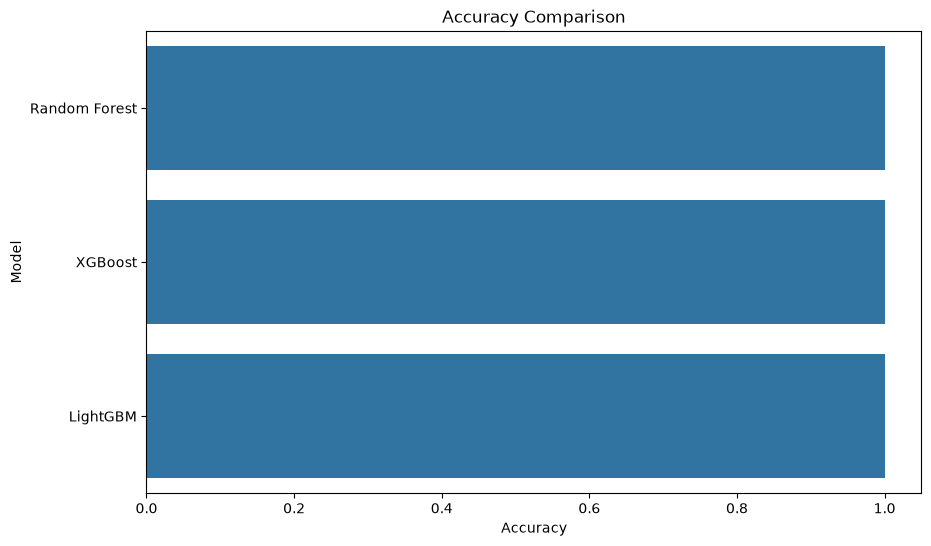

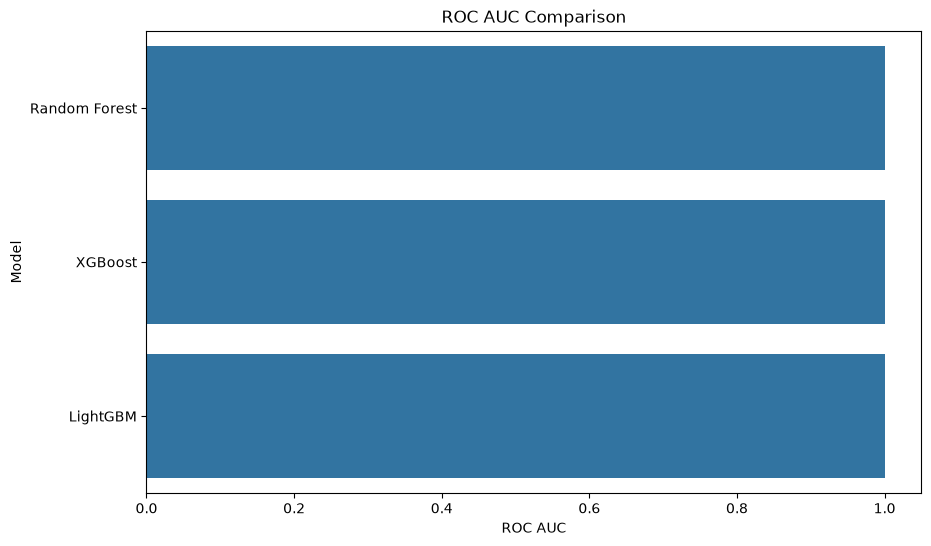

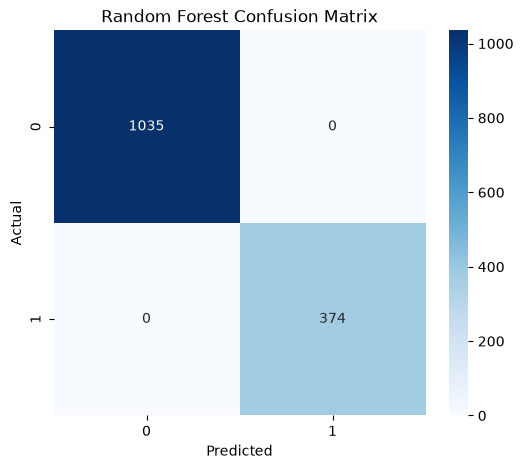

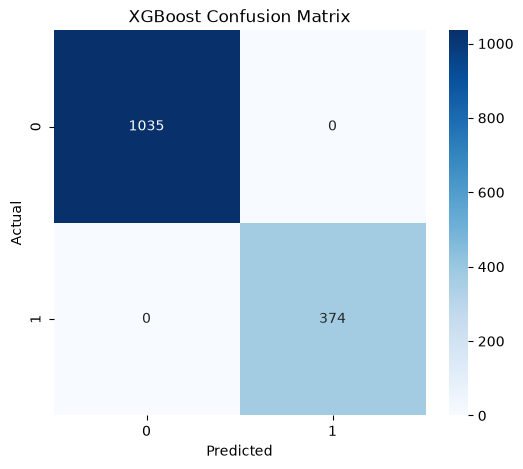

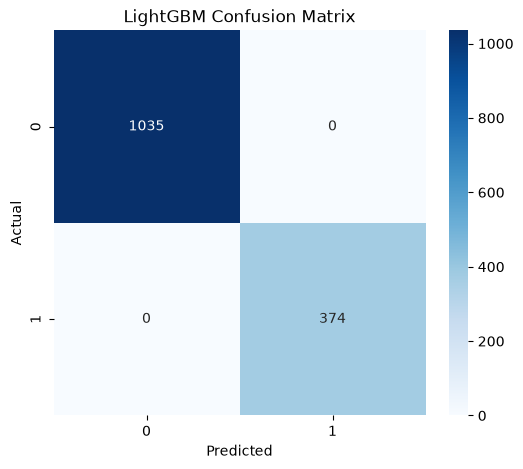

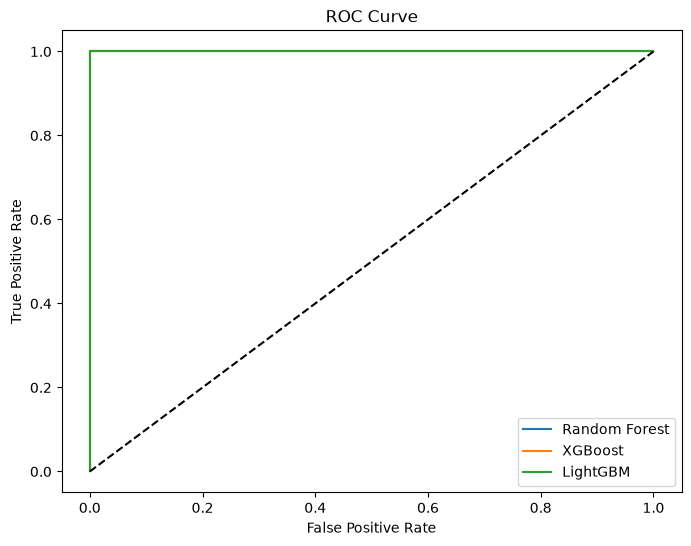

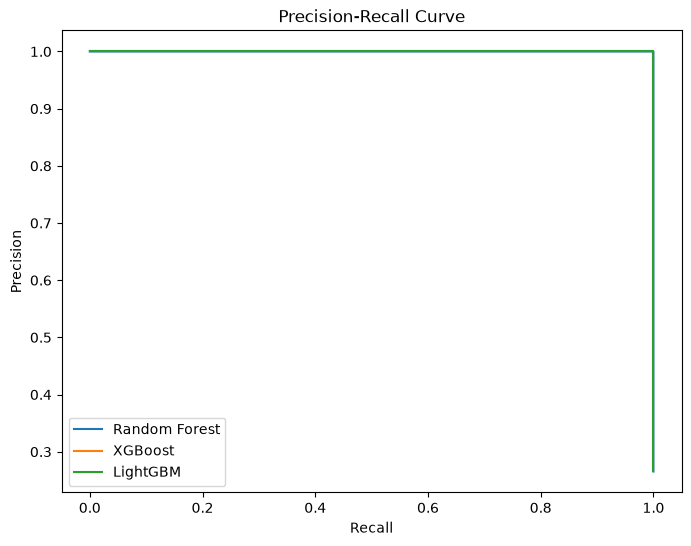

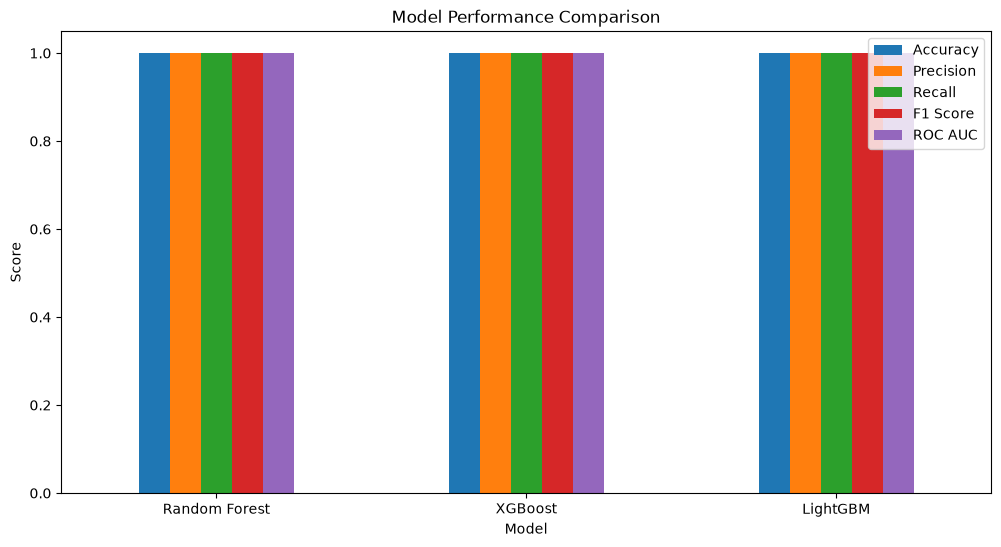

In [2]:
# -----------------------------
# Phase 10 - Model Evaluation
# -----------------------------


# -----------------------------
# Import Libraries
# -----------------------------
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# -----------------------------
# Create output folders
# -----------------------------
SAVE_PATH = "../images/08_Model_Evaluation"
REPORT_PATH = "../reports"

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)

# -----------------------------
# Load test data
# -----------------------------
X_test = joblib.load("../data/processed/X_test.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

# Optional scaled test data if needed later
X_test_scaled = joblib.load("../data/processed/X_test_scaled.pkl")

# -----------------------------
# Load tuned models
# -----------------------------
rf = joblib.load("../models/random_forest_tuned.pkl")
xgb = joblib.load("../models/xgboost_tuned.pkl")
lgbm = joblib.load("../models/lightgbm_tuned.pkl")

# -----------------------------
# Model dictionary
# -----------------------------
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

results = []

# -----------------------------
# Evaluate models
# -----------------------------
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, y_pred))

# -----------------------------
# Results table
# -----------------------------
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df

# -----------------------------
# Save results
# -----------------------------
results_df.to_excel("../reports/model_evaluation.xlsx", index=False)
results_df.to_csv("../reports/model_evaluation.csv", index=False)

# -----------------------------
# Accuracy comparison graph
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Accuracy Comparison")
plt.savefig(
    os.path.join(SAVE_PATH, "Accuracy_Comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# ROC-AUC comparison graph
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="ROC AUC", y="Model")
plt.title("ROC AUC Comparison")
plt.savefig(
    os.path.join(SAVE_PATH, "ROC_AUC_Comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# Confusion matrices
# -----------------------------
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(
        os.path.join(SAVE_PATH, f"{name}_Confusion_Matrix.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# -----------------------------
# ROC curve
# -----------------------------
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(
    os.path.join(SAVE_PATH, "ROC_Curve.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# Precision-Recall curve
# -----------------------------
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig(
    os.path.join(SAVE_PATH, "Precision_Recall_Curve.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# Overall metric comparison
# -----------------------------
metrics = results_df.set_index("Model")

metrics.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.savefig(
    os.path.join(SAVE_PATH, "Overall_Model_Comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# Best model by ROC AUC
# -----------------------------
best_model = results_df.sort_values(by="ROC AUC", ascending=False)
best_model

# -----------------------------
# Save best model summary
# -----------------------------
best_model.to_excel("../reports/best_model.xlsx", index=False)

In [3]:
# Observations

# The tuned models were evaluated using:

# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - ROC AUC

# The model with the highest ROC AUC and balanced Precision-Recall performance was selected as the final model for deployment.